<p style="text-align: center; margin-bottom: 0; font-size: 24px;">EAE1106 - Métodos Computacionais para Economia</p>
<p style="text-align: center; margin-bottom: 0;">Faculdade de Economia, Administração, Contabilidade e Atuária<br>Universidade de São Paulo</p>
<p style="text-align: center; margin-top: 5px;">1º semestre de 2026<br><br>Prof. Arthur Viaro</p>

# Aula 22 — Visualização de Dados com Matplotlib

**Conteúdo**

- [O que é o Matplotlib?](#intro)
- [Construindo nosso 1º gráfico](#primeiro)
- [Personalização](#personalizacao)
- [Múltiplos gráficos](#multiplos)
- [Outros tipos de gráficos](#outros)
- [Visualização e storytelling](#storytelling)

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## O que é o Matplotlib? <a id="intro"></a>

Até aqui trabalhamos principalmente com tabelas, vetores e operações numéricas. Entretanto, grande parte da análise empírica em Economia depende da capacidade de explorar padrões visualmente. Gráficos permitem identificar tendências, distribuições, relações entre variáveis e possíveis problemas nos dados antes mesmo de qualquer modelagem estatística.

O **Matplotlib** é a principal biblioteca de visualização em Python. Ela oferece controle detalhado sobre praticamente todos os elementos visuais de uma figura: eixos, títulos, legendas, cores, escalas e múltiplos gráficos. Embora existam outras bibliotecas (e.g., `altair`, `bokeh`, `plotly`) que permitem visualizações dinâmicas e interativas, o Matplotlib é uma excelente primeira abordagem — e para a esmagadora maioria das aplicações em Economia, é essa biblioteca que buscaremos primeiro.

Em relação aos dados, utilizaremos os dados da [**Penn World Table versão 11.0**](https://www.rug.nl/ggdc/productivity/pwt/?lang=en) — base com informações sobre renda, produto e produtividade de mais de 180 países entre 1950 e 2023. As principais variáveis que usaremos são:

| Variável | Descrição |
|----------|-----------|
| `country` | Nome do país |
| `year` | Ano |
| `pop` | População (milhões) |
| `emp` | Pessoas empregadas (milhões) |
| `avh` | Número médio de horas trabalhadas por trabalhador no ano |
| `rgdpna` | PIB real (contas nacionais, milhões de USD de 2017) |

In [2]:
columns_to_read = ['country', 'year', 'pop', 'emp', 'rgdpna', 'avh']
df_pwt = pd.read_csv('pwt110.csv', usecols=columns_to_read)
df_pwt.info()

<class 'pandas.DataFrame'>
RangeIndex: 13690 entries, 0 to 13689
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  13690 non-null  str    
 1   year     13690 non-null  int64  
 2   pop      11201 non-null  float64
 3   emp      10307 non-null  float64
 4   avh      5015 non-null   float64
 5   rgdpna   11201 non-null  float64
dtypes: float64(4), int64(1), str(1)
memory usage: 641.8 KB


## Construindo nosso 1º gráfico <a id="primeiro"></a>

Com o DataFrame carregado, podemos plotar a evolução das **horas trabalhadas no Brasil** ao longo do tempo. Para isso usaremos a variável `avh`, que contabiliza o número médio de horas trabalhadas por trabalhador ao longo de um ano. Para uma representação mais intuitiva, dividiremos esse número por 260 — o número aproximado de dias úteis em um ano — convertendo para **horas médias por dia útil**.

Passamos à função `plt.plot()` os valores do eixo `x` (ano) e do eixo `y` (horas trabalhadas por dia útil) e chamamos `plt.show()` para exibir o gráfico.

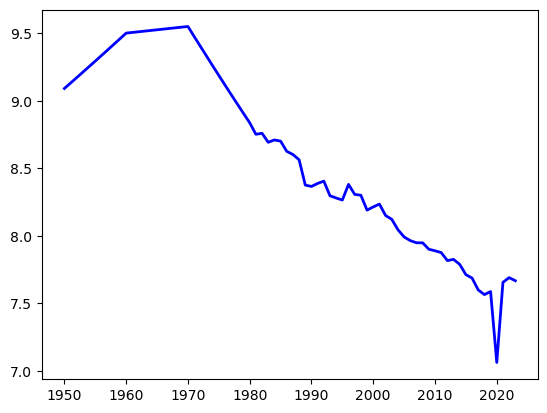

In [3]:
df_pwtbr = df_pwt.loc[df_pwt['country'] == 'Brazil', :].reset_index(drop=True)

x = df_pwtbr['year']
y = df_pwtbr['avh'] / 260

plt.plot(x, y, 'b-', linewidth=2)
plt.show()

O gráfico está feito, mas ficou um pouco feio. Como podemos melhorá-lo?

- Ajustar o que mostramos nos eixos X e Y.
- Mudar a cor da linha para algo mais agradável.
- Colocar um marcador em cada ponto de dado.
- Adicionar título ao gráfico.

Para ajustar o eixo Y é importante conhecer os limites numéricos da variável. Vamos usar `.describe()` para isso:

In [4]:
df_pwtbr.describe()

,year,pop,emp,avh,rgdpna
count,74.000000,74.000000,74.000000,74.000000,7.400000e+01
mean,1986.500000,136.750821,53.572123,2241.467162,1.803295e+06
std,21.505813,50.964024,26.716314,177.901795,1.197112e+06
min,1950.000000,53.270684,15.605801,1836.490000,1.734005e+05
25%,1968.250000,90.911177,26.349119,2081.415000,5.999789e+05
50%,1986.500000,139.720657,55.667509,2239.540000,1.840248e+06
75%,2004.750000,184.184861,77.850891,2413.975000,2.703407e+06
max,2023.000000,211.140729,99.297546,2482.770000,3.904424e+06


Agora podemos usar as informações de escala para aplicar todas as melhorias sugeridas ao gráfico de uma só vez:

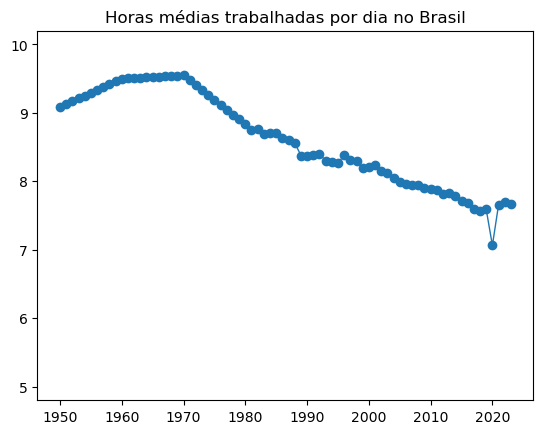

In [5]:
x_ticks  = [1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]
x_labels = ['1950','1960','1970','1980','1990','2000','2010','2020']
y_ticks  = [5, 6, 7, 8, 9, 10]
y_labels = ['5','6','7','8','9','10']

plt.plot(x, y, color='#1f77b4', linewidth=1, marker='o')

plt.xticks(x_ticks, x_labels)
plt.yticks(y_ticks, y_labels)
plt.ylim([4.8, 10.2])
plt.title('Horas médias trabalhadas por dia no Brasil')
plt.show()

## Personalização <a id="personalizacao"></a>

O gráfico anterior representa corretamente os dados, mas ainda tem aparência bastante simples. Em aplicações reais, precisamos ajustar elementos visuais para melhorar legibilidade e comunicação.

Uma das belezas do Python é sua lógica multiparadigma. Na estratégia que acabamos de usar, muitos dos objetos que compõem o gráfico (eixos, fundo, bordas) são criados e transmitidos sem se tornarem conhecidos pelo programador. Em geral é preferível um estilo mais **explícito e orientado a objetos**, que nos dá mais controle sobre cada dimensão do gráfico.

Começamos com a função `plt.subplots()`, que retorna dois objetos — que nomeamos como `fig` e `ax`:
- **`fig`** é como um fundo branco — o "canvas" que contém tudo.
- **`ax`** é o painel onde o gráfico é desenhado (com eixos, linhas, pontos etc.).

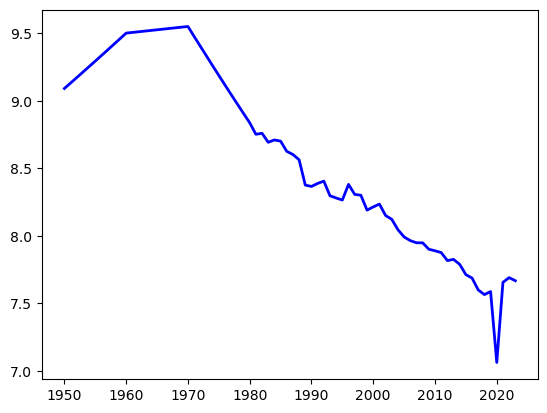

In [6]:
fig, ax = plt.subplots()

ax.plot(x, y, 'b-', linewidth=2)
plt.show()

O resultado é o mesmo, mas agora temos acesso explícito aos objetos. Para entender a diferença entre `fig` e `ax`, veja o exemplo abaixo — pintamos cada um de uma cor diferente:

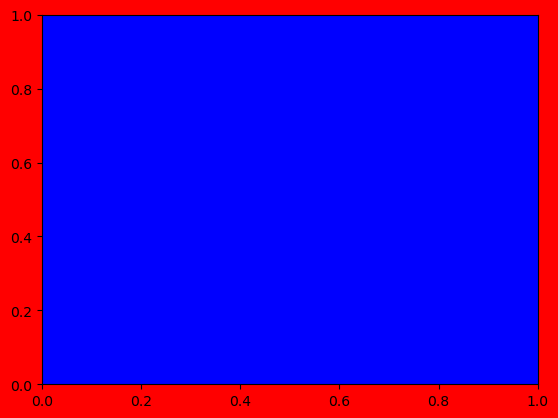

In [7]:
fig, ax = plt.subplots()

fig.set_facecolor("red")   # fundo da figura
ax.set_facecolor("blue")   # área do gráfico

plt.show()

Com essa lógica orientada a objetos, como replicamos o 2º gráfico da seção anterior?

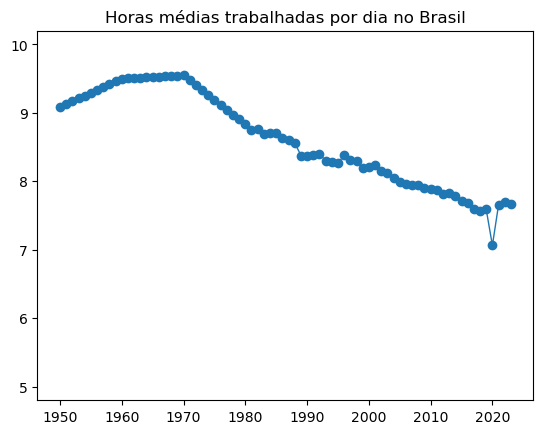

In [8]:
x_ticks  = [1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020]
x_labels = ['1950','1960','1970','1980','1990','2000','2010','2020']
y_ticks  = [5, 6, 7, 8, 9, 10]
y_labels = ['5','6','7','8','9','10']

fig, ax = plt.subplots()

ax.plot(x, y, color='#1f77b4', linewidth=1, marker='o')
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels)
ax.set_ylim(4.8, 10.2)

plt.title('Horas médias trabalhadas por dia no Brasil')
plt.show()

Foram mais linhas de código, mas essa abordagem orientada a objetos nos permite muito mais personalizações. Vamos deixá-lo melhor ainda, fazendo alterações uma a uma para comparar os resultados.

### Partes de um Gráfico

Antes de criar gráficos com o Matplotlib, é importante conhecer os principais componentes de uma figura (Figure). Cada elemento possui uma função específica na organização e visualização dos dados.

A imagem abaixo apresenta a anatomia básica de um gráfico no Matplotlib:

<img src="https://matplotlib.org/stable/_images/anatomy.png" width="700">

Entre os principais componentes, destacam-se:

- `Figure`: a área total da figura, que contém todos os elementos do gráfico;
- `Axes`: a região onde os dados são efetivamente desenhados;
- `Axis`: os eixos horizontal (x) e vertical (y);
- `Title`: o título do gráfico;
- `Labels`: os rótulos dos eixos;
- `Legend`: a legenda que identifica os elementos plotados;
- `Grid`: a grade auxiliar para leitura dos valores.

Compreender essa estrutura facilita a personalização e a criação de visualizações mais claras e profissionais.


**Passo 1 — Ajustar a proporção e remover bordas desnecessárias:**

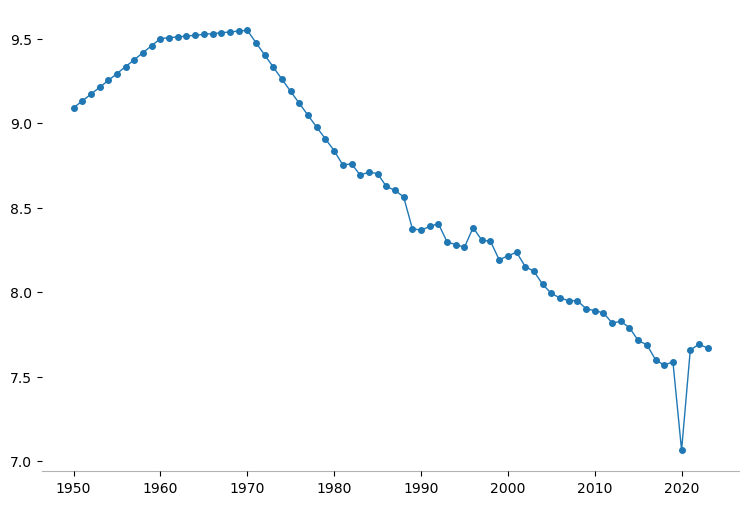

In [29]:
height = 6
fig, ax = plt.subplots(1, 1, figsize=(1.50 * height, height))

ax.plot(x, y, color='#1f77b4', linewidth=1, marker='o', markersize=4)

# Visibilidade das bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_alpha(0.3)

plt.show()

**Passo 2 — Adicionar linhas de grade para o eixo Y:**

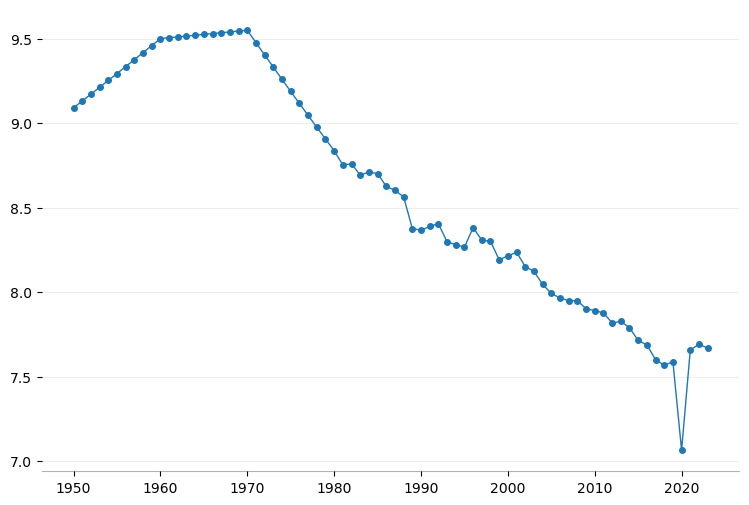

In [10]:
height = 6
fig, ax = plt.subplots(1, 1, figsize=(1.50 * height, height))

ax.plot(x, y, color='#1f77b4', linewidth=1, marker='o', markersize=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_alpha(0.3)

# Linhas de grade
ax.grid(visible=True, which='major', axis='y', ls='-', lw=0.5, c='k', alpha=0.1)

plt.show()

**Passo 3 — Ajustar marcadores e limites dos eixos:**

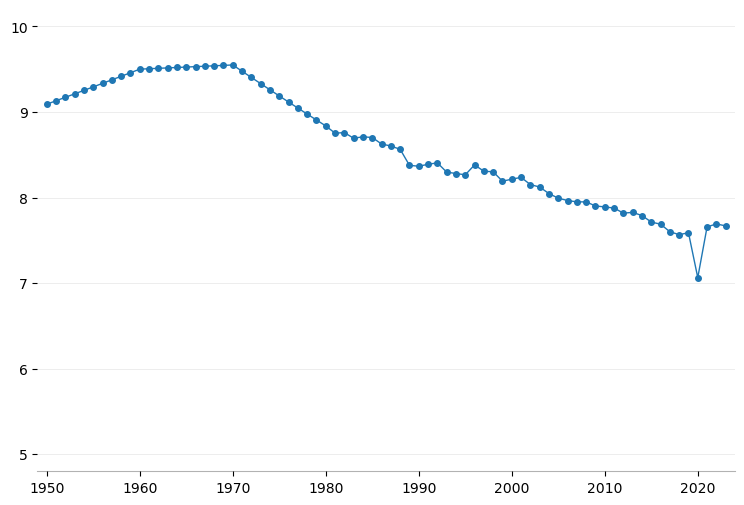

In [11]:
height = 6
fig, ax = plt.subplots(1, 1, figsize=(1.50 * height, height))

ax.plot(x, y, color='#1f77b4', linewidth=1, marker='o', markersize=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_alpha(0.3)

ax.grid(visible=True, which='major', axis='y', ls='-', lw=0.5, c='k', alpha=0.1)

# Marcadores dos eixos
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=10, fontweight='light')
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=10, fontweight='light')

# Limites dos eixos
ax.set_xlim(1949, 2024)
ax.set_ylim(4.8, 10.2)

plt.show()

**Passo 4 — Adicionar uma linha de referência com a média histórica:**

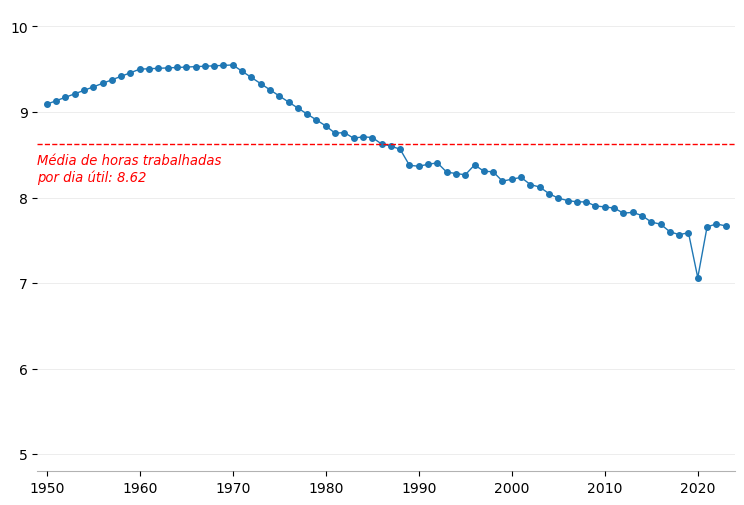

In [12]:
height = 6
fig, ax = plt.subplots(1, 1, figsize=(1.50 * height, height))

ax.plot(x, y, color='#1f77b4', linewidth=1, marker='o', markersize=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_alpha(0.3)

ax.grid(visible=True, which='major', axis='y', ls='-', lw=0.5, c='k', alpha=0.1)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=10, fontweight='light')
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=10, fontweight='light')

ax.set_xlim(1949, 2024)
ax.set_ylim(4.8, 10.2)

# Linha de referência: média histórica
ax.plot([1949, 2024], [y.mean(), y.mean()], 'r--', lw=1.0)
ax.annotate(
    'Média de horas trabalhadas\npor dia útil: {:,.2f}'.format(y.mean()),
    xy=(1949, 0.95 * y.mean()),
    fontsize=9.5, color='r', fontweight='normal', style='italic'
)

plt.show()

**Passo 5 — Adicionar título, fonte dos dados e salvar a figura:**

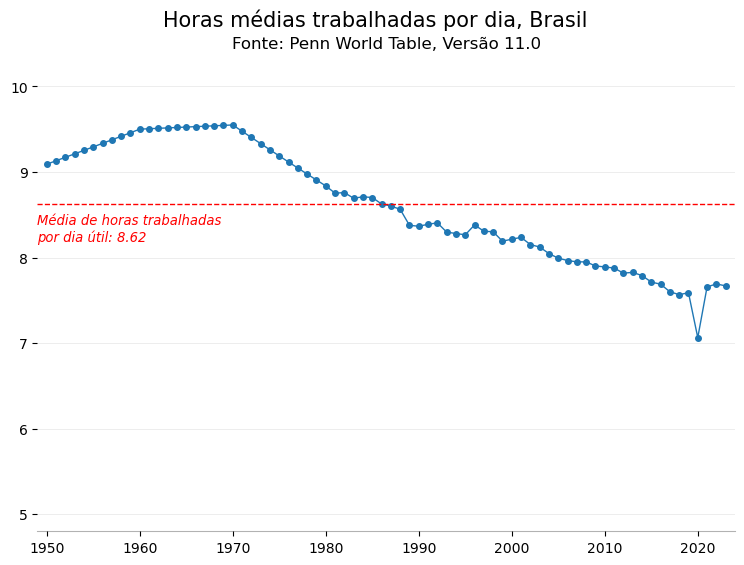

In [13]:
height = 6
fig, ax = plt.subplots(1, 1, figsize=(1.50 * height, height))

ax.plot(x, y, color='#1f77b4', linewidth=1, marker='o', markersize=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_alpha(0.3)

ax.grid(visible=True, which='major', axis='y', ls='-', lw=0.5, c='k', alpha=0.1)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=10, fontweight='light')
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=10, fontweight='light')

ax.set_xlim(1949, 2024)
ax.set_ylim(4.8, 10.2)

ax.plot([1949, 2024], [y.mean(), y.mean()], 'r--', lw=1.0)
ax.annotate(
    'Média de horas trabalhadas\npor dia útil: {:,.2f}'.format(y.mean()),
    xy=(1949, 0.95 * y.mean()),
    fontsize=9.5, color='r', fontweight='normal', style='italic'
)

# Título e fonte
plt.suptitle('Horas médias trabalhadas por dia, Brasil', fontsize=15, fontweight='normal')
plt.title('Fonte: Penn World Table, Versão 11.0', fontsize=12, fontweight='normal', pad=15)

plt.savefig('avhbr_pwt11.png', bbox_inches='tight')
plt.show()

Que diferença! Foram muitas linhas de código, mas esse é o preço de um bom gráfico. O controle sobre todos os elementos que compõem uma figura é essencial para tornar visualizações cada vez mais informativas.

## Múltiplos gráficos <a id="multiplos"></a>

Até aqui trabalhamos com figuras contendo apenas um gráfico. Em aplicações empíricas, porém, é comum comparar diferentes séries ou combinar múltiplas visualizações em uma mesma figura.

### Várias séries em um mesmo gráfico

Em posse dos dados de horas trabalhadas por país, uma pergunta natural é: como evoluiu ao longo do tempo o número médio de horas trabalhadas no Brasil comparado a outros países? Basta adicionar mais chamadas a `ax.plot()` para sobrepor séries.

In [14]:
anos_comuns = df_pwt.loc[df_pwt['country'] == 'Brazil', 'year']

y1 = df_pwt.loc[df_pwt['country'] == 'Brazil',         'avh'].values / 260
y2 = df_pwt.loc[df_pwt['country'] == 'United States',  'avh'].values / 260

# Alinhar pelo mesmo índice de anos
anos_comuns = anos_comuns.values

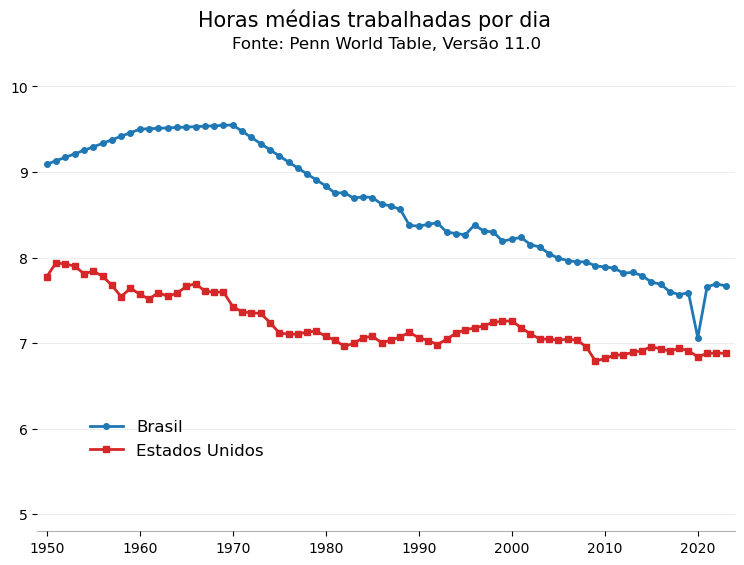

In [15]:
height = 6
fig, ax = plt.subplots(1, 1, figsize=(1.50 * height, height))

ax.plot(anos_comuns, y1, color='#1f77b4', linewidth=2, marker='o', markersize=4, label='Brasil')
ax.plot(anos_comuns, y2, color='#d62728', linewidth=2, marker='s', markersize=4, label='Estados Unidos')

# Legenda
ax.legend(loc='center', bbox_to_anchor=(0.2, 0.2), framealpha=0, ncol=1, prop={'size': 12})

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_alpha(0.3)

ax.grid(visible=True, which='major', axis='y', ls='-', lw=0.5, c='k', alpha=0.1)

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, fontsize=10, fontweight='light')
ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize=10, fontweight='light')

ax.set_xlim(1949, 2024)
ax.set_ylim(4.8, 10.2)

plt.suptitle('Horas médias trabalhadas por dia', fontsize=15, fontweight='normal')
plt.title('Fonte: Penn World Table, Versão 11.0', fontsize=12, fontweight='normal', pad=15)

plt.savefig('avh_countries_pwt11.png', bbox_inches='tight')
plt.show()

### Vários gráficos dentro da mesma figura

Outra alternativa é colocar cada série em um painel separado. Para tal, basta alterar os dois primeiros argumentos de `plt.subplots()`, que representam o **número de linhas** e o **número de colunas** da grade de painéis.

Quando há mais de um painel, `ax` deixa de ser um único objeto e vira um **array NumPy** de objetos — acessamos cada painel com `ax[i]`.

- Com `(1, 1)`, `ax` é um único objeto Matplotlib:


<class 'matplotlib.axes._axes.Axes'>


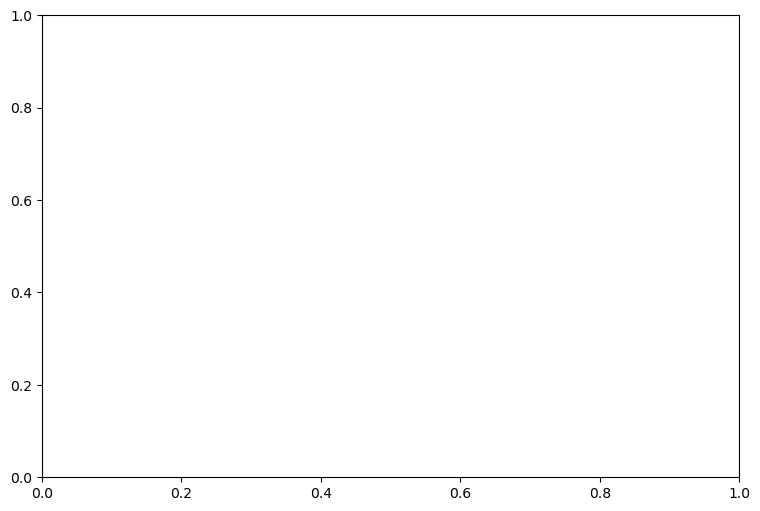

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
print(type(ax))
#plt.close()

- Com `(2, 1)`, `ax` é um array NumPy:

<class 'numpy.ndarray'>


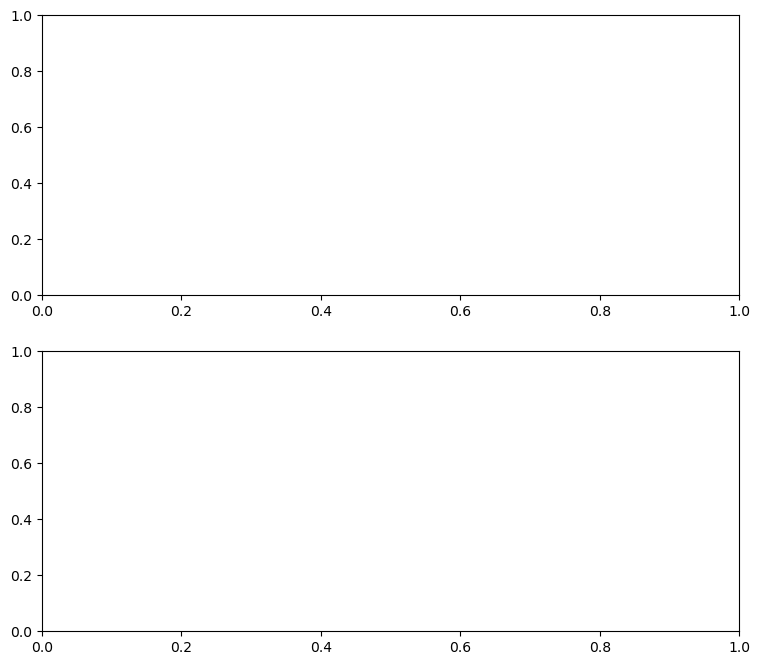

In [33]:
fig, ax = plt.subplots(2, 1, figsize=(9, 8))
print(type(ax))
#plt.close()

Com múltiplos painéis, usamos um loop para aplicar as mesmas personalizações a cada painel individualmente:

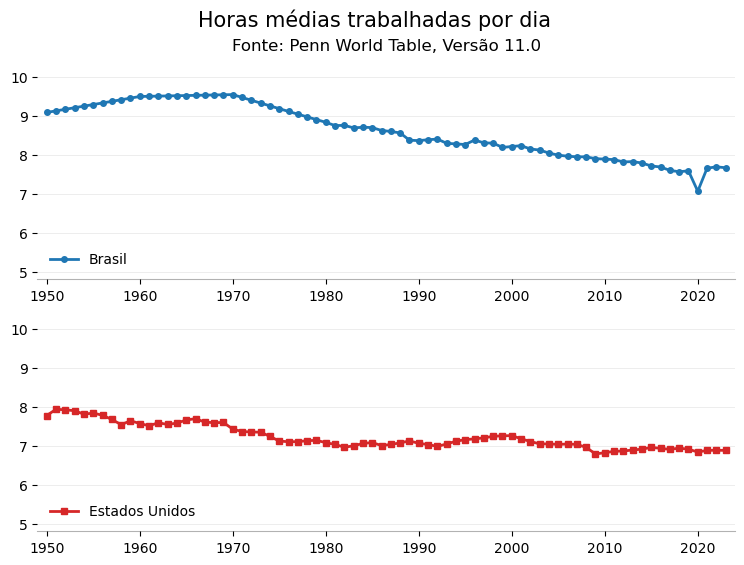

In [44]:
height = 6
fig, ax = plt.subplots(2, 1, figsize=(1.50 * height, height))

# Séries a serem plotadas
ax[0].plot(anos_comuns, y1, color='#1f77b4', linewidth=2, marker='o', markersize=4, label='Brasil')
ax[1].plot(anos_comuns, y2, color='#d62728', linewidth=2, marker='s', markersize=4, label='Estados Unidos')

for i in range(2):
    # Legenda
    ax[i].legend(loc='lower left', framealpha=0, prop={'size': 10})

    # Visibilidade das bordas
    ax[i].spines['top'].set_visible(False)
    ax[i].spines['right'].set_visible(False)
    ax[i].spines['left'].set_visible(False)
    ax[i].spines['bottom'].set_visible(True)
    ax[i].spines['bottom'].set_alpha(0.3)

    # Linhas de grid
    ax[i].grid(visible=True, which='major', axis='y', ls='-', lw=0.5, c='k', alpha=0.1)

    # Marcadores dos eixos
    ax[i].set_xticks(x_ticks)
    ax[i].set_xticklabels(x_labels, fontsize=10, fontweight='light')
    ax[i].set_yticks(y_ticks)
    ax[i].set_yticklabels(y_labels, fontsize=10, fontweight='light')

    # Limites dos eixos
    ax[i].set_xlim(1949, 2024)
    ax[i].set_ylim(4.8, 10.2)

# Título e fonte
plt.suptitle('Horas médias trabalhadas por dia', fontsize=15, fontweight='normal')
plt.title('Fonte: Penn World Table, Versão 11.0', fontsize=12, fontweight='normal', pad=195)

# Salvar a figura e mostrar o resultado
plt.savefig('avh_countries2_pwt11.png', bbox_inches='tight')
plt.show()

## Outros tipos de gráficos <a id="outros"></a>

O gráfico de linha não é a única visualização disponível no Matplotlib, e muitas vezes nem é a mais adequada. Quando queremos comparar categorias, analisar distribuições ou investigar a relação entre variáveis, outros tipos de gráficos podem representar os dados de forma mais clara.

### Gráfico de dispersão

Gráficos de linha são úteis para representar a evolução ao longo do tempo, mas menos adequados quando o objetivo é investigar a **relação entre duas variáveis**. Para isso, usamos o gráfico de dispersão (`scatter`), que representa pares de valores nos dois eixos.

Vamos analisar a relação entre **horas trabalhadas** e **PIB per capita** em 2010. À primeira vista, poderíamos imaginar que países nos quais as pessoas trabalham mais horas tendem a ser mais ricos. Por outro lado, países mais ricos geralmente possuem legislações que limitam a jornada, pois maior produtividade permite produzir mais com menos horas. O gráfico de dispersão pode nos ajudar a visualizar qual relação prevalece.

Como o PIB per capita costuma ser muito assimétrico entre países, é mais informativo analisar o **logaritmo** do PIB per capita.

In [19]:
df_pwt['pibpc'] = df_pwt['rgdpna'] / df_pwt['pop']

x_scatter = df_pwt.loc[df_pwt['year'] == 2010, 'avh'] / 260
y_scatter = np.log(df_pwt.loc[df_pwt['year'] == 2010, 'pibpc'])

x_ticks_sc = [5, 7, 9, 11]
x_labels_sc = ['5', '7', '9', '11']
y_ticks_sc = [5, 7, 9, 11, 13]
y_labels_sc = ['5', '7', '9', '11', '13']

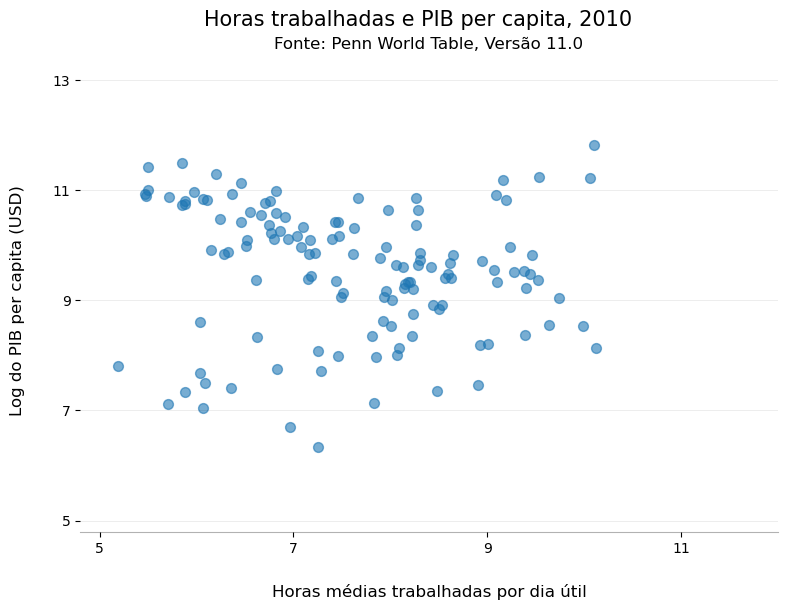

In [ ]:
height = 6
fig, ax = plt.subplots(1, 1, figsize=(1.50 * height, height))

# Séries a serem plotadas
ax.scatter(x_scatter, y_scatter, color='#1f77b4', marker='o', s=50, alpha=0.6)

# Visibilidade das bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_alpha(0.3)

# Linhas de grid
ax.grid(visible=True, which='major', axis='y', ls='-', lw=0.5, c='k', alpha=0.1)

# Marcadores dos eixos
ax.set_xticks(x_ticks_sc)
ax.set_xticklabels(x_labels_sc, fontsize=10, fontweight='light')
ax.set_yticks(y_ticks_sc)
ax.set_yticklabels(y_labels_sc, fontsize=10, fontweight='light')

# Limites e título dos eixos
ax.set_xlim(4.8, 12)
ax.set_ylim(4.8, 13.2)
ax.set_xlabel('Horas médias trabalhadas por dia útil', fontsize=12, fontweight='light', labelpad=20)
ax.set_ylabel('Log do PIB per capita (USD)', fontsize=12, fontweight='light', labelpad=20)

# Título e fonte
plt.suptitle('Horas trabalhadas e PIB per capita, 2010', fontsize=15, fontweight='normal')
plt.title('Fonte: Penn World Table, Versão 11.0', fontsize=12, fontweight='normal', pad=15)

# Salvar a figura e mostrar o resultado
plt.savefig('avh_pibpc_scatter.png', bbox_inches='tight')
plt.show()

A simples visualização do gráfico de dispersão não nos permite tirar conclusões imediatas — não parece haver uma relação clara entre as variáveis. Que tal refazer a análise olhando por grupo de país (desenvolvido vs. em desenvolvimento) ou para um único país ao longo do tempo?

### Gráfico de barras

O gráfico de barras serve muito ao propósito de comparar uma variável entre **grupos ou categorias** em um dado momento do tempo. Dentre os 10 países com maior PIB per capita em 2010, quais têm o maior número médio de horas trabalhadas?

In [21]:
df_top10 = df_pwt[df_pwt['year'] == 2010].copy()
df_top10.sort_values('pibpc', ascending=False, ignore_index=True, inplace=True)
df_top10.dropna(inplace=True)
df_top10 = df_top10.iloc[:10, :].reset_index(drop=True)

# Abreviar nomes longos para não lotarem o eixo
df_top10['country'] = df_top10['country'].str.replace('United Arab Emirates', 'UAE')
df_top10['country'] = df_top10['country'].str.replace('United States', 'EUA')

df_top10[['country', 'pibpc', 'avh']]

,country,pibpc,avh
0,Qatar,137070.857313,2627.29
1,Luxembourg,97859.919124,1521.01
2,Norway,91396.944660,1429.86
3,Switzerland,81224.348315,1611.29
4,Singapore,76848.733084,2478.71
5,UAE,75050.127998,2615.65
6,Kuwait,72516.153454,2383.22
7,Ireland,68125.333126,1680.74
8,Netherlands,60913.559735,1430.15
9,EUA,59465.698228,1773.37


**Barra vertical** (`ax.bar`):

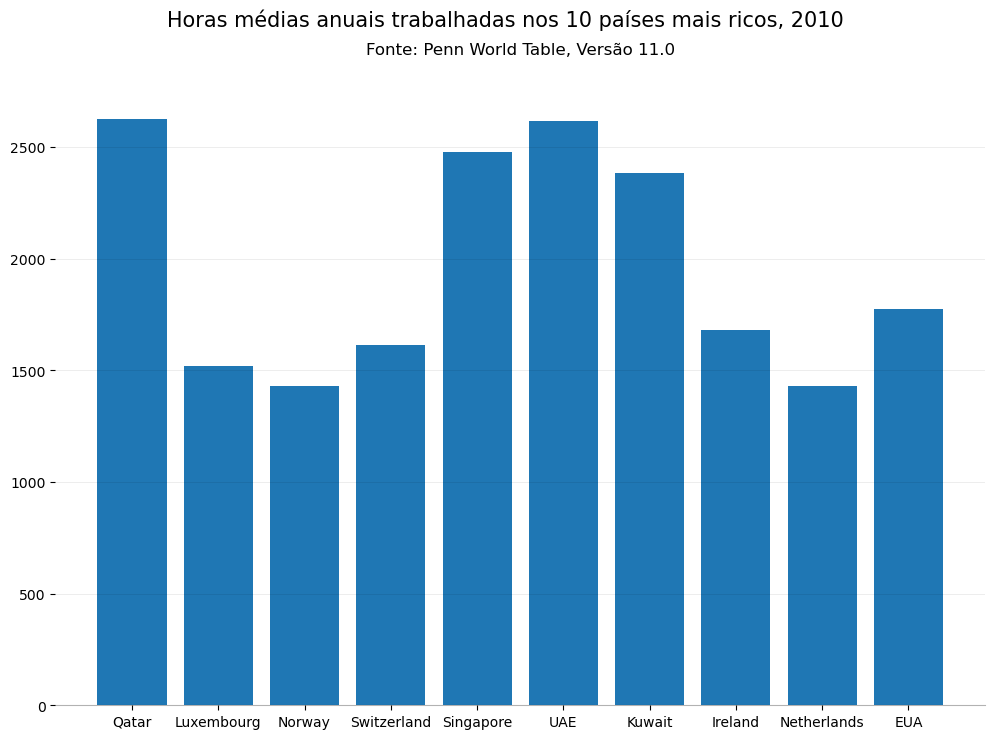

In [ ]:
x_bar = df_top10['country']
y_bar = df_top10['avh']

height = 8
fig, ax = plt.subplots(1, 1, figsize=(1.50 * height, height))

# Séries a serem plotadas
ax.bar(x_bar, y_bar, align='center', color='#1f77b4')

# Visibilidade das bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_alpha(0.3)

# Linhas de grid
ax.grid(visible=True, which='major', axis='y', ls='-', lw=0.5, c='k', alpha=0.1)

# Título e fonte
plt.suptitle('Horas médias anuais trabalhadas nos 10 países mais ricos, 2010', fontsize=15, fontweight='normal')
plt.title('Fonte: Penn World Table, Versão 11.0', fontsize=12, fontweight='normal', pad=25)

# Salvar a figura e mostrar o resultado
plt.savefig('avh_bar.png', bbox_inches='tight')
plt.show()

**Barra horizontal** (`ax.barh`) — muitas vezes mais legível quando os nomes das categorias são longos:

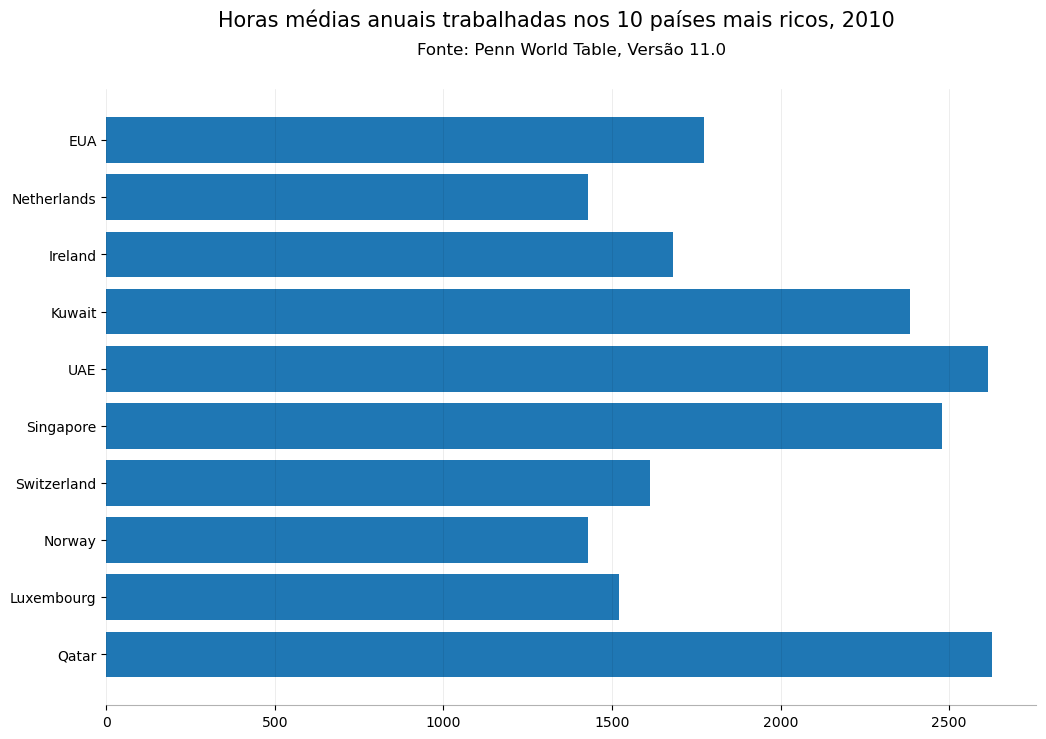

In [ ]:
height = 8
fig, ax = plt.subplots(1, 1, figsize=(1.50 * height, height))

# Séries a serem plotadas
ax.barh(x_bar, y_bar, align='center', color='#1f77b4')

# Visibilidade das bordas
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_alpha(0.3)

# Linhas de grid
ax.grid(visible=True, which='major', axis='x', ls='-', lw=0.5, c='k', alpha=0.1)

# Título e fonte
plt.suptitle('Horas médias anuais trabalhadas nos 10 países mais ricos, 2010', fontsize=15, fontweight='normal')
plt.title('Fonte: Penn World Table, Versão 11.0', fontsize=12, fontweight='normal', pad=25)

# Salvar a figura e mostrar o resultado
plt.savefig('avh_barh.png', bbox_inches='tight')
plt.show()

### Histograma

O histograma mostra a **distribuição de uma variável contínua**, dividindo os dados em intervalos e contando quantas observações caem em cada um. Vamos plotar em uma mesma figura os histogramas de 4 variáveis diferentes para o ano de 2010: `pop`, `emp`, `avh` e o log do `pibpc`.

In [24]:
df_2010 = df_pwt[df_pwt['year'] == 2010].copy()
df_2010.dropna(inplace=True)
df_2010['log_pibpc'] = np.log(df_2010['pibpc'])

# Excluir China e Índia (mais de 1 bilhão de hab.) para melhor visualização
df_2010 = df_2010.loc[df_2010['pop'] < 1000, :]

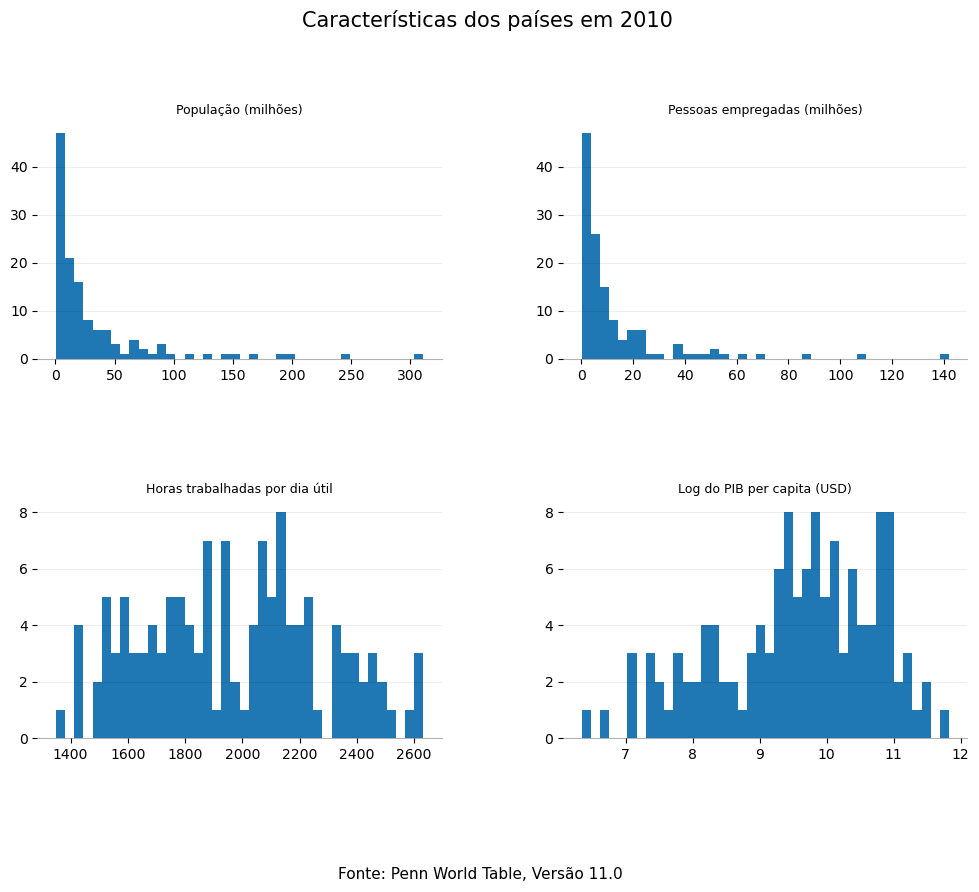

In [ ]:
height = 8
fig, ax = plt.subplots(2, 2, figsize=(1.50 * height, height))

# Séries a serem plotadas
ax[0, 0].hist(df_2010['pop'],       color='#1f77b4', bins=40)
ax[0, 1].hist(df_2010['emp'],       color='#1f77b4', bins=40)
ax[1, 0].hist(df_2010['avh'],       color='#1f77b4', bins=40)
ax[1, 1].hist(df_2010['log_pibpc'], color='#1f77b4', bins=40)

ax[0, 0].set_title('População (milhões)',              fontsize=9, fontweight='light')
ax[0, 1].set_title('Pessoas empregadas (milhões)',     fontsize=9, fontweight='light')
ax[1, 0].set_title('Horas trabalhadas por dia útil',  fontsize=9, fontweight='light')
ax[1, 1].set_title('Log do PIB per capita (USD)',      fontsize=9, fontweight='light')

for r in range(2):
    for c in range(2):
        # Visibilidade das bordas
        ax[r, c].spines['top'].set_visible(False)
        ax[r, c].spines['right'].set_visible(False)
        ax[r, c].spines['left'].set_visible(False)
        ax[r, c].spines['bottom'].set_visible(True)
        ax[r, c].spines['bottom'].set_alpha(0.3)
        # Linhas de grid
        ax[r, c].grid(visible=True, which='major', axis='y', ls='-', lw=0.5, c='k', alpha=0.1)

# Ajuste de espaço entre os vários plots
fig.subplots_adjust(hspace=0.6, wspace=0.3)

# Título e fonte
plt.suptitle('Características dos países em 2010', y=1.02, fontsize=15, fontweight='normal')
plt.text(2.7, -5, 'Fonte: Penn World Table, Versão 11.0', fontsize=11, fontweight='normal')

# Salvar a figura e mostrar o resultado
plt.savefig('carac_countries_all.png', bbox_inches='tight')
plt.show()

## Visualização e storytelling <a id="storytelling"></a>

É parte importante do dia-a-dia de um economista ser capaz de **comunicar resultados** de uma análise ou pesquisa. E como há muito tempo se sabe: uma imagem vale mais do que mil palavras.

No artigo [*An Economist's Guide to Visualizing Data*](https://pubs.aeaweb.org/doi/pdf/10.1257/jep.28.1.209) (JEP, 2014), Jonathan Schwabish aponta três princípios básicos para uma boa visualização:

1. **Mostre os dados.** O conjunto de dados é o elemento básico da história que se quer contar. Não é preciso mostrar tudo, mas o que for mostrado deve ser claro.

2. **Reduza a sujeira gráfica.** Elementos visuais desnecessários ou que distraem (bordas grossas, cores muito próximas, texturas, pontos de referência em excesso) tendem a reduzir a eficácia do gráfico.

3. **Texto e imagem devem funcionar juntos.** Elementos textuais podem ajudar a chamar atenção para o ponto principal — o gráfico deve se sustentar sozinho, mas também funcionar como complemento ao texto.

Em resumo: construir um bom gráfico é um exercício de **criatividade e muita tentativa e erro**. A palavra-chave é **personalização**.